In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

Validation Accuracy: 0.9560439560439561


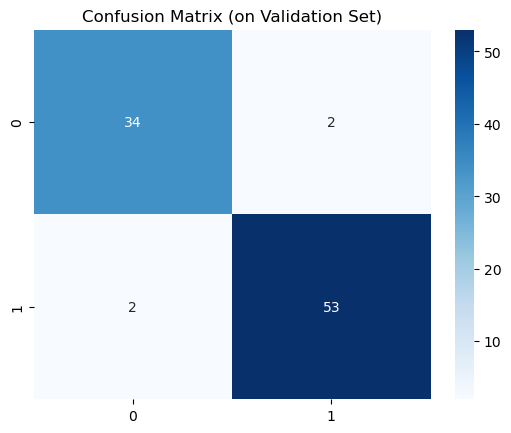

In [2]:
y_pred_val = log_reg.predict(X_val_scaled)

sns.heatmap(
    data=confusion_matrix(y_val, y_pred_val),
    annot=True,
    cmap="Blues"
)
plt.title("Confusion Matrix (on Validation Set)")

acc_ = accuracy_score(y_val, y_pred_val)
print(f"Validation Accuracy: {acc_}")

Validation Accuracy: 0.9824561403508771


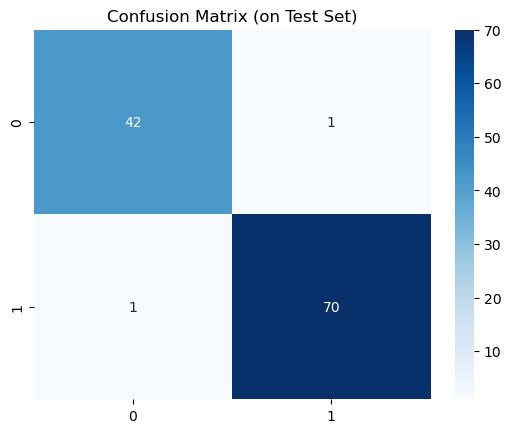

In [3]:
y_pred = log_reg.predict(X_test_scaled)

sns.heatmap(
    data=confusion_matrix(y_test, y_pred),
    annot=True,
    cmap="Blues"
)
plt.title("Confusion Matrix (on Test Set)")

print(f"Validation Accuracy: {accuracy_score(y_test, y_pred)}")

In [4]:
p = log_reg.predict_proba(X_test_scaled)
labels = p[:, 1] > 0.5
y_pred = []
for label in labels:
    if label:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [5]:
log_reg.decision_function(X_test_scaled)

array([ 2.25739474e+00, -1.15049223e+01, -6.19074323e+00,  7.68977714e+00,
        1.05090038e+01, -2.55834556e+01, -2.09091529e+01, -2.92282665e+00,
        5.48877775e-01,  7.25565862e+00,  2.77283842e+00, -3.89268267e+00,
        5.33833423e+00, -1.89177290e+00,  7.06733477e+00, -6.44920057e+00,
        6.70503340e+00,  1.27180444e+01,  1.59169293e+01, -1.44941741e+01,
        2.66377235e+00,  5.15101871e+00, -2.06769238e+01,  1.04053752e+01,
        7.23860371e+00,  8.26548015e+00,  7.00292519e+00,  5.45758066e+00,
        6.28362801e+00, -1.28195569e+01,  7.78215458e+00,  9.86799239e+00,
        7.40851815e+00,  5.50762242e+00,  9.89375871e+00,  6.78334646e+00,
       -2.60069668e+00,  7.57890379e+00, -9.72826421e+00,  2.94524728e+00,
        9.97863403e+00, -7.69054925e+00,  6.19528630e+00,  7.34775179e+00,
        5.86671565e+00,  2.85180313e+00,  9.07001506e+00,  9.11065213e+00,
        3.26797618e+00,  7.78063320e+00, -9.65534474e+00, -1.78005989e+01,
        5.21688559e-01,  

In [6]:
log_reg.get_params(deep=True)

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [7]:
log_reg.predict_proba(X_test_scaled)

array([[9.47135155e-02, 9.05286485e-01],
       [9.99989920e-01, 1.00802513e-05],
       [9.97955883e-01, 2.04411685e-03],
       [4.57270920e-04, 9.99542729e-01],
       [2.72888842e-05, 9.99972711e-01],
       [1.00000000e+00, 7.74901360e-12],
       [9.99999999e-01, 8.30367402e-10],
       [9.48963373e-01, 5.10366270e-02],
       [3.66124813e-01, 6.33875187e-01],
       [7.05668810e-04, 9.99294331e-01],
       [5.88097067e-02, 9.41190293e-01],
       [9.80016895e-01, 1.99831046e-02],
       [4.78089940e-03, 9.95219101e-01],
       [8.68957543e-01, 1.31042457e-01],
       [8.51776056e-04, 9.99148224e-01],
       [9.98420712e-01, 1.57928810e-03],
       [1.22323367e-03, 9.98776766e-01],
       [2.99655458e-06, 9.99997003e-01],
       [1.22282805e-07, 9.99999878e-01],
       [9.99999493e-01, 5.07294274e-07],
       [6.51452153e-02, 9.34854785e-01],
       [5.76012851e-03, 9.94239871e-01],
       [9.99999999e-01, 1.04743257e-09],
       [3.02684263e-05, 9.99969732e-01],
       [7.177984

In [8]:
log_reg.predict_log_proba(X_test_scaled)

array([[-2.35689857e+00, -9.95038279e-02],
       [-1.00803022e-05, -1.15049324e+01],
       [-2.04620890e-03, -6.19278944e+00],
       [-7.69023452e+00, -4.57375500e-04],
       [-1.05090311e+01, -2.72892565e-05],
       [-7.74902365e-12, -2.55834556e+01],
       [-8.30367442e-10, -2.09091529e+01],
       [-5.23850765e-02, -2.97521173e+00],
       [-1.00478098e+00, -4.55903210e-01],
       [-7.25636454e+00, -7.05917912e-04],
       [-2.83344836e+00, -6.06099353e-02],
       [-2.01854672e-02, -3.91286813e+00],
       [-5.34312659e+00, -4.79236446e-03],
       [-1.40461012e-01, -2.03223391e+00],
       [-7.06818691e+00, -8.52139023e-04],
       [-1.58053649e-03, -6.45078110e+00],
       [-6.70625738e+00, -1.22398243e-03],
       [-1.27180474e+01, -2.99655907e-06],
       [-1.59169294e+01, -1.22282812e-07],
       [-5.07294403e-07, -1.44941746e+01],
       [-2.73113642e+00, -6.73640723e-02],
       [-5.15679549e+00, -5.77678203e-03],
       [-1.04743259e-09, -2.06769238e+01],
       [-1.

In [9]:
log_reg.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [10]:
print(f"Accuracy with regularization: {acc_}")

import numpy as np
log_reg.set_params(C=np.inf)
acc_ = accuracy_score(
    y_test, log_reg.predict(X_test_scaled)
)
print(f"Accuracy without regularization: {acc_}")

Accuracy with regularization: 0.9560439560439561
Accuracy without regularization: 0.9824561403508771


C=1.00
Sparsity with L1 penalty:                6.25%
Sparsity with Elastic-Net penalty:       4.69%
Sparsity with L2 penalty:                4.69%
Score with L1 penalty:                   0.90
Score with Elastic-Net penalty:          0.90
Score with L2 penalty:                   0.90
C=0.10
Sparsity with L1 penalty:                25.00%
Sparsity with Elastic-Net penalty:       10.94%
Sparsity with L2 penalty:                4.69%
Score with L1 penalty:                   0.90
Score with Elastic-Net penalty:          0.90
Score with L2 penalty:                   0.90
C=0.01
Sparsity with L1 penalty:                84.38%
Sparsity with Elastic-Net penalty:       65.62%
Sparsity with L2 penalty:                4.69%
Score with L1 penalty:                   0.86
Score with Elastic-Net penalty:          0.88
Score with L2 penalty:                   0.89


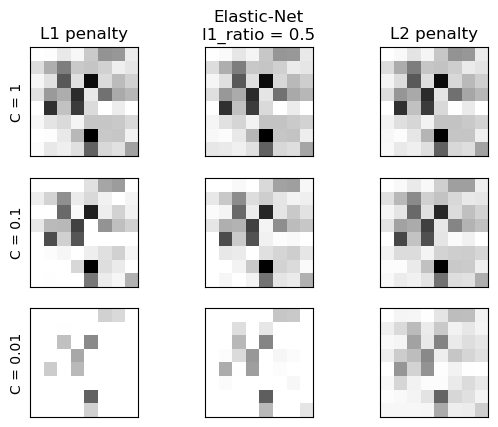

In [14]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X, y = datasets.load_digits(return_X_y=True)

X = StandardScaler().fit_transform(X)

# classify small against large digits
y = (y > 4).astype(int)

l1_ratio = 0.5  # L1 weight in the Elastic-Net regularization

fig, axes = plt.subplots(3, 3)

# Set regularization parameter
for i, (C, axes_row) in enumerate(zip((1, 0.1, 0.01), axes)):
    # Increase tolerance for short training time
    clf_l1_LR = LogisticRegression(C=C, l1_ratio=1, tol=0.01, solver="saga")
    clf_l2_LR = LogisticRegression(C=C, l1_ratio=0, tol=0.01, solver="saga")
    clf_en_LR = LogisticRegression(C=C, l1_ratio=l1_ratio, tol=0.01, solver="saga")
    clf_l1_LR.fit(X, y)
    clf_l2_LR.fit(X, y)
    clf_en_LR.fit(X, y)

    coef_l1_LR = clf_l1_LR.coef_.ravel()
    coef_l2_LR = clf_l2_LR.coef_.ravel()
    coef_en_LR = clf_en_LR.coef_.ravel()

    # coef_l1_LR contains zeros due to the
    # L1 sparsity inducing norm

    sparsity_l1_LR = np.mean(coef_l1_LR == 0) * 100
    sparsity_l2_LR = np.mean(coef_l2_LR == 0) * 100
    sparsity_en_LR = np.mean(coef_en_LR == 0) * 100

    print(f"C={C:.2f}")
    print(f"{'Sparsity with L1 penalty:':<40} {sparsity_l1_LR:.2f}%")
    print(f"{'Sparsity with Elastic-Net penalty:':<40} {sparsity_en_LR:.2f}%")
    print(f"{'Sparsity with L2 penalty:':<40} {sparsity_l2_LR:.2f}%")
    print(f"{'Score with L1 penalty:':<40} {clf_l1_LR.score(X, y):.2f}")
    print(f"{'Score with Elastic-Net penalty:':<40} {clf_en_LR.score(X, y):.2f}")
    print(f"{'Score with L2 penalty:':<40} {clf_l2_LR.score(X, y):.2f}")

    if i == 0:
        axes_row[0].set_title("L1 penalty")
        axes_row[1].set_title("Elastic-Net\nl1_ratio = %s" % l1_ratio)
        axes_row[2].set_title("L2 penalty")

    for ax, coefs in zip(axes_row, [coef_l1_LR, coef_en_LR, coef_l2_LR]):
        ax.imshow(
            np.abs(coefs.reshape(8, 8)),
            interpolation="nearest",
            cmap="binary",
            vmax=1,
            vmin=0,
        )
        ax.set_xticks(())
        ax.set_yticks(())

    axes_row[0].set_ylabel(f"C = {C}")

plt.show()

In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# make iris dataset binary
iris = load_iris(as_frame=True)
iris = iris['frame']
iris = iris[iris['target'] != 2]
X = iris.drop('target', axis=1).to_numpy()
y = iris['target'].to_numpy()

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

# standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# train model
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [17]:
y_pred_val = model.predict(X_val_scaled)

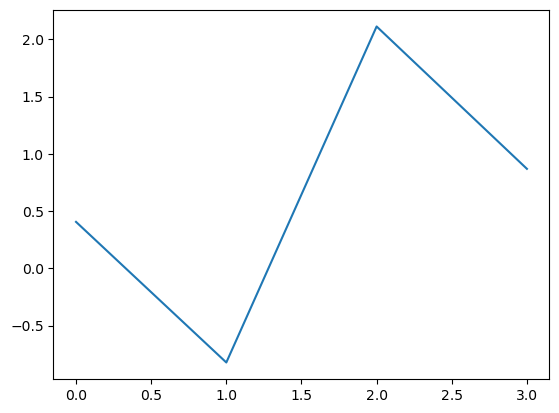

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(range(len(model.coef_[0])), model.coef_[0])

In [32]:
range(0, len(model.coef_[0]))

range(0, 4)

Accuracy: 0.95


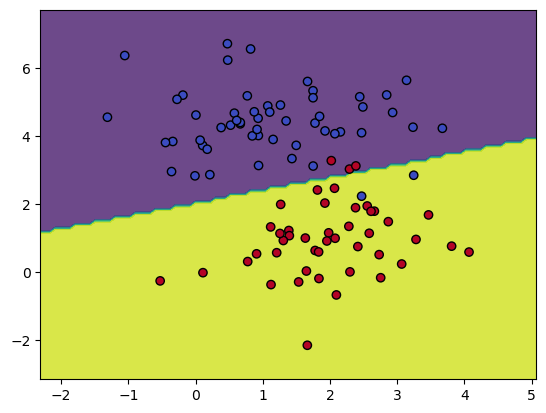

In [50]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Generate sample data
X, y = make_blobs(n_samples=500, centers=2, random_state=0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a logistic regression model
model = LogisticRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

from sklearn.inspection import DecisionBoundaryDisplay

# Visualize the decision boundary
fig, ax = plt.subplots()
DecisionBoundaryDisplay.from_estimator(model, X_test, ax=plt.gca(), multiclass_colors='coolwarm', alpha=0.8, response_method="predict")
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors="Black")

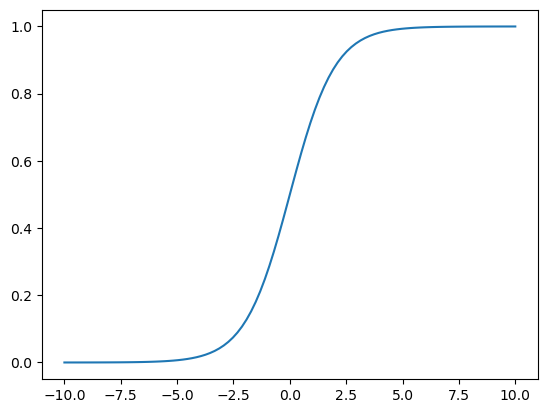

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def logit(probability):
    return np.log(probability / (1 - probability))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

z = np.linspace(-10, 10, 100)

plt.plot(z, sigmoid(z))

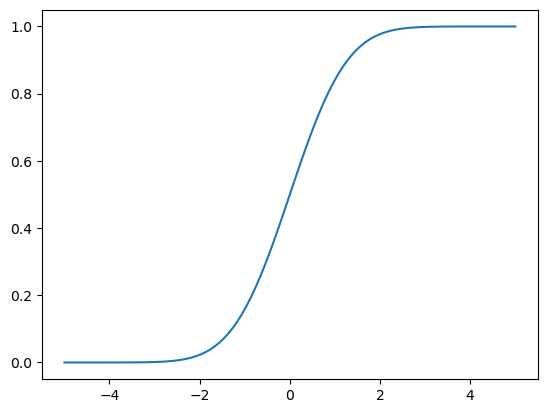

In [19]:
from scipy.stats import norm

def normal_dis_cdf(x):
	return norm.cdf(x)

def inverse_normal_cdf(p, mu, sigma):
	return norm.ppf(p, mu, sigma)

z = np.linspace(-5, 5, 100)

plt.plot(z, normal_dis_cdf(z))

In [ ]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X = X.filter(regex="mean|worst")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
